In [2]:
!pip install ucimlrepo xgboost scikit-learn pandas numpy matplotlib seaborn

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached xgboost-3.4.1-py3-none-manylinux_2_28_x86_64.whl.metadata (2.0 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.3 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached contourpy-1.4.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Using cached xgboost-3.4.1-py3-none-manylinux_2_28_x86_64.whl (57.6 MB)
Using cached scikit_learn-1.9.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.2 MB)
Using cached matplotlib-3.11.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (11.0 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cach

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [ ]:
Phần A BỘ DỮ LIỆU OULAD

In [15]:
!pip install kagglehub[pandas-datasets]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kagglehub]/4 [kagglesdk]


In [16]:



import kagglehub
from kagglehub import KaggleDatasetAdapter

DATASET_ID = "anlgrbz/student-demographics-online-education-dataoulad"

def load_oulad_file(filename):
    return kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATASET_ID,
        filename
    )

assessments        = load_oulad_file("assessments.csv")
courses             = load_oulad_file("courses.csv")
studentAssessment   = load_oulad_file("studentAssessment.csv")
studentInfo          = load_oulad_file("studentInfo.csv")
studentRegistration = load_oulad_file("studentRegistration.csv")
studentVle           = load_oulad_file("studentVle.csv")
vle                  = load_oulad_file("vle.csv")

print("Số dòng mỗi bảng OULAD:")
for name, df in [("assessments", assessments), ("courses", courses),
                  ("studentAssessment", studentAssessment), ("studentInfo", studentInfo),
                  ("studentRegistration", studentRegistration), ("studentVle", studentVle),
                  ("vle", vle)]:
    print(f"  {name:20s}: {df.shape}")

100%|██████████| 8.01k/8.01k [00:00<00:00, 18.8MB/s]


100%|██████████| 526/526 [00:00<00:00, 1.02MB/s]


100%|██████████| 0.99M/0.99M [00:01<00:00, 847kB/s]

Extracting zip of studentAssessment.csv...


100%|██████████| 319k/319k [00:00<00:00, 392kB/s]

...

Extracting zip of studentRegistration.csv...


100%|██████████| 40.6M/40.6M [00:03<00:00, 12.8MB/s]

Extracting zip of studentVle.csv...


100%|██████████| 254k/254k [00:00<00:00, 313kB/s]

Số dòng mỗi bảng OULAD:
  assessments         : (206, 6)
  courses             : (22, 3)
  studentAssessment   : (173912, 5)
  studentInfo         : (32593, 12)
  studentRegistration : (32593, 5)
  studentVle          : (10655280, 6)
  vle                 : (6364, 6)


Phân bố kết quả học tập (final_result):
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


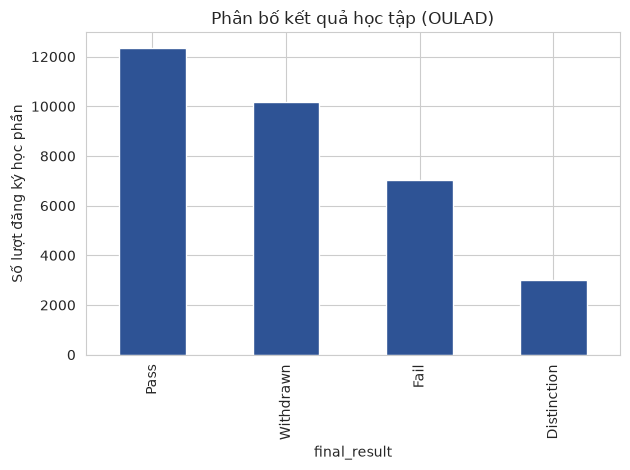


Số giá trị thiếu theo cột:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64


In [11]:
print("Phân bố kết quả học tập (final_result):")
print(studentInfo['final_result'].value_counts())

studentInfo['final_result'].value_counts().plot(kind='bar', title='Phân bố kết quả học tập (OULAD)', color='#2E5395')
plt.ylabel('Số lượt đăng ký học phần')
plt.tight_layout()
plt.show()

print("\nSố giá trị thiếu theo cột:")
print(studentInfo.isnull().sum())

In [17]:


# 3.1 Tổng số click trên VLE mỗi sinh viên trong mỗi lượt học -> đại diện mức độ tương tác LMS
vle_clicks = studentVle.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index()
vle_clicks.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# 3.2 Điểm trung bình các bài đánh giá quá trình (TMA) -> đại diện "điểm giữa kỳ"
sa = studentAssessment.merge(assessments, on='id_assessment', how='left')
sa_tma = sa[sa['assessment_type'] == 'TMA']
midterm_scores = sa_tma.groupby(['id_student', 'code_module', 'code_presentation'])['score'].mean().reset_index()
midterm_scores.rename(columns={'score': 'avg_tma_score'}, inplace=True)

# 3.3 Ghép vào bảng chính
oulad = studentInfo.merge(vle_clicks, on=['id_student', 'code_module', 'code_presentation'], how='left')
oulad = oulad.merge(midterm_scores, on=['id_student', 'code_module', 'code_presentation'], how='left')

# 3.4 Điền thiếu: không có click/điểm coi như thiếu tương tác -> 0
oulad['total_clicks'] = oulad['total_clicks'].fillna(0)
oulad['avg_tma_score'] = oulad['avg_tma_score'].fillna(0)

print(oulad.shape)
oulad.head()


(32593, 14)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,avg_tma_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,82.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,66.4
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,76.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,54.4


In [18]:
# ==== A4. Gán nhãn 3 mức rủi ro A(Cao)/B(Trung bình)/C(Thấp) ====
# Withdrawn, Fail -> A (nguy cơ cao)
# Distinction -> C (nguy cơ thấp)
# Pass -> chia tiếp B/C dựa trên NGƯỠNG LÀ MEDIAN điểm TMA thực tế của chính nhóm Pass
#         (không chọn tùy tiện, có căn cứ từ phân bố dữ liệu)
pass_median = oulad.loc[oulad['final_result'] == 'Pass', 'avg_tma_score'].median()
print("Ngưỡng median điểm TMA của nhóm Pass:", pass_median)

def assign_risk(row):
    if row['final_result'] in ['Withdrawn', 'Fail']:
        return 'A'
    elif row['final_result'] == 'Distinction':
        return 'C'
    elif row['final_result'] == 'Pass':
        return 'B' if row['avg_tma_score'] < pass_median else 'C'
    return np.nan

oulad['risk_level'] = oulad.apply(assign_risk, axis=1)
print("\nPhân bố nhãn rủi ro OULAD:")
print(oulad['risk_level'].value_counts())

Ngưỡng median điểm TMA của nhóm Pass: 74.83333333333333

Phân bố nhãn rủi ro OULAD:
risk_level
A    17208
C     9216
B     6169
Name: count, dtype: int64


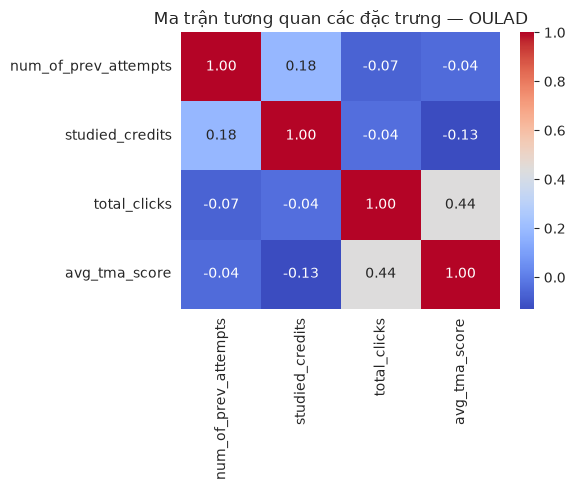

In [19]:
# ==== A5. Ma trận tương quan giữa các đặc trưng số (khám phá mối quan hệ dữ liệu) ====
numeric_cols_oulad = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'avg_tma_score']
corr_oulad = oulad[numeric_cols_oulad].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_oulad, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan các đặc trưng — OULAD')
plt.tight_layout()
plt.show()

In [21]:

feature_cols_oulad = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'avg_tma_score']

oulad_model_df = oulad.dropna(subset=['risk_level']).copy()

le_oulad = LabelEncoder()
oulad_model_df['risk_label_enc'] = le_oulad.fit_transform(oulad_model_df['risk_level'])  # A,B,C -> số

X_oulad = oulad_model_df[feature_cols_oulad]
y_oulad = oulad_model_df['risk_label_enc']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_oulad, y_oulad, test_size=0.2, random_state=RANDOM_STATE, stratify=y_oulad
)
print("Train:", X_train_o.shape, " Test:", X_test_o.shape)
print("Ánh xạ nhãn:", dict(zip(le_oulad.classes_, le_oulad.transform(le_oulad.classes_))))


Train: (26074, 4)  Test: (6519, 4)
Ánh xạ nhãn: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2)}


In [22]:
# ==== A7. Huấn luyện & đánh giá mô hình Random Forest và XGBoost trên OULAD ====
rf_oulad = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
rf_oulad.fit(X_train_o, y_train_o)
pred_rf_o = rf_oulad.predict(X_test_o)
xgb_oulad = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='mlogloss')
xgb_oulad.fit(X_train_o, y_train_o)
pred_xgb_o = xgb_oulad.predict(X_test_o)

print("=== Random Forest — OULAD ===")
print(classification_report(y_test_o, pred_rf_o, target_names=le_oulad.classes_))
print("=== XGBoost — OULAD ===")
print(classification_report(y_test_o, pred_xgb_o, target_names=le_oulad.classes_))

=== Random Forest — OULAD ===
              precision    recall  f1-score   support

           A       0.87      0.74      0.80      3442
           B       0.59      0.76      0.66      1234
           C       0.84      0.91      0.87      1843

    accuracy                           0.79      6519
   macro avg       0.77      0.80      0.78      6519
weighted avg       0.81      0.79      0.79      6519

=== XGBoost — OULAD ===
              precision    recall  f1-score   support

           A       0.84      0.82      0.83      3442
           B       0.65      0.67      0.66      1234
           C       0.87      0.90      0.88      1843

    accuracy                           0.81      6519
   macro avg       0.79      0.79      0.79      6519
weighted avg       0.81      0.81      0.81      6519



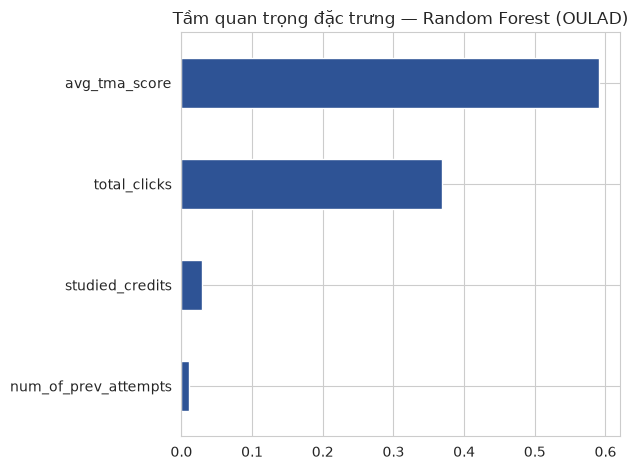

In [23]:
# ==== A8. Tầm quan trọng đặc trưng (feature importance) — OULAD ====
importances_o = pd.Series(rf_oulad.feature_importances_, index=feature_cols_oulad).sort_values()
importances_o.plot(kind='barh', title='Tầm quan trọng đặc trưng — Random Forest (OULAD)', color='#2E5395')
plt.tight_layout()
plt.show()
